In [1]:
#1. Data overview
import pandas as pd

# Para ver todas las columnas
pd.set_option('display.max_columns', None)

# Para ver todas las filas
#pd.set_option('display.max_rows', None)

#1.1 Cargar el dataset
df = pd.read_excel("Telco_Churn_EDA.xlsx")

#1.2 Dimensión del dataset
df.shape

(7043, 21)

In [2]:
#7.2 Definir x e y
X = df.drop("Churn Value", axis=1)
y = df["Churn Value"]

In [3]:
#7.3 Train/Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [4]:
#7.4 Identificar columnas
num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["str"]).columns

In [5]:
#7.5 Preprocesador
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

num_transformer = StandardScaler()
cat_transformer = OneHotEncoder(drop="first", handle_unknown="ignore")

preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_transformer, num_cols),
        ("cat", cat_transformer, cat_cols)
    ]
)

In [18]:
#7.6 Pipeline con SMOTE + XGBoost
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

pipeline_xgb_smote = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", XGBClassifier(
        random_state=42,
        n_estimators=200,
        max_depth=4,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss"
    ))
])

In [19]:
#7.7 Entrenar
pipeline_xgb_smote.fit(X_train, y_train)

,steps,"[('preprocessing', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. Th

In [20]:
# 8.2 Optimización de hiperparámetros para XGBoost
from sklearn.model_selection import GridSearchCV

# Definir la cuadrícula de valores a probar
# OJO: Mantenemos el prefijo 'model__' porque así llamaste al paso en tu Pipeline
param_grid_xgb = {
    'model__n_estimators': [100, 200, 300],         # Número de árboles
    'model__learning_rate': [0.01, 0.05, 0.1],      # Tasa de aprendizaje
    'model__max_depth': [3, 4, 5],                  # Profundidad de cada árbol
    'model__subsample': [0.8, 1.0],                 # % de filas usadas por árbol
    'model__colsample_bytree': [0.8, 1.0]           # % de columnas usadas por árbol
}

# Configurar GridSearchCV
grid_search_xgb = GridSearchCV(
    estimator=pipeline_xgb_smote,
    param_grid=param_grid_xgb,
    scoring='roc_auc',      # Seguimos usando ROC-AUC por el desbalanceo
    cv=5,                   # Validación cruzada de 5 pliegues
    n_jobs=-1,              # Usa todos los núcleos de Colab
    verbose=2               # Para ir viendo el progreso (XGBoost suele tardar más)
)

# Entrenar probando todas las combinaciones
print("Iniciando entrenamiento y optimización de XGBoost...")
grid_search_xgb.fit(X_train, y_train)

# Mostrar los mejores resultados encontrados
print("\n--- Resultados de GridSearchCV para XGBoost ---")
print(f"Mejor ROC-AUC en entrenamiento (CV): {grid_search_xgb.best_score_:.4f}")
print("Mejores hiperparámetros encontrados:")
print(grid_search_xgb.best_params_)

# Extraer el mejor modelo para usarlo en adelante
best_pipeline_xgb = grid_search_xgb.best_estimator_

Iniciando entrenamiento y optimización de XGBoost...
Fitting 5 folds for each of 108 candidates, totalling 540 fits

--- Resultados de GridSearchCV para XGBoost ---
Mejor ROC-AUC en entrenamiento (CV): 0.8619
Mejores hiperparámetros encontrados:
{'model__colsample_bytree': 0.8, 'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 200, 'model__subsample': 0.8}


In [21]:
#7.8 Predicciones
y_pred_xgb_smote = best_pipeline_xgb.predict(X_test)
# Sacamos las probabilidades del modelo XGBoost optimizado
y_prob_xgb_smote = best_pipeline_xgb.predict_proba(X_test)[:, 1]

# (El resto del código del bucle for y el plot.plot() de la respuesta anterior funciona tal cual)

In [22]:
#7.9 Evaluación
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

print(confusion_matrix(y_test, y_pred_xgb_smote))
print(classification_report(y_test, y_pred_xgb_smote))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb_smote))

[[842 193]
 [112 262]]
              precision    recall  f1-score   support

           0       0.88      0.81      0.85      1035
           1       0.58      0.70      0.63       374

    accuracy                           0.78      1409
   macro avg       0.73      0.76      0.74      1409
weighted avg       0.80      0.78      0.79      1409

ROC-AUC: 0.8519646593815392


--- Tabla de Métricas por Umbral ---
 threshold   recall  precision       f1
      0.10 0.965241   0.407449 0.573016
      0.15 0.941176   0.434568 0.594595
      0.20 0.922460   0.452163 0.606860
      0.25 0.879679   0.470672 0.613234
      0.30 0.847594   0.491473 0.622179
      0.35 0.807487   0.502496 0.619487
      0.40 0.775401   0.529197 0.629067
      0.45 0.735294   0.551102 0.630011
      0.50 0.700535   0.575824 0.632087
      0.55 0.655080   0.597561 0.625000
      0.60 0.585561   0.613445 0.599179
      0.65 0.534759   0.666667 0.593472
      0.70 0.467914   0.714286 0.565428
      0.75 0.344920   0.728814 0.468240
      0.80 0.270053   0.770992 0.400000
      0.85 0.163102   0.802632 0.271111


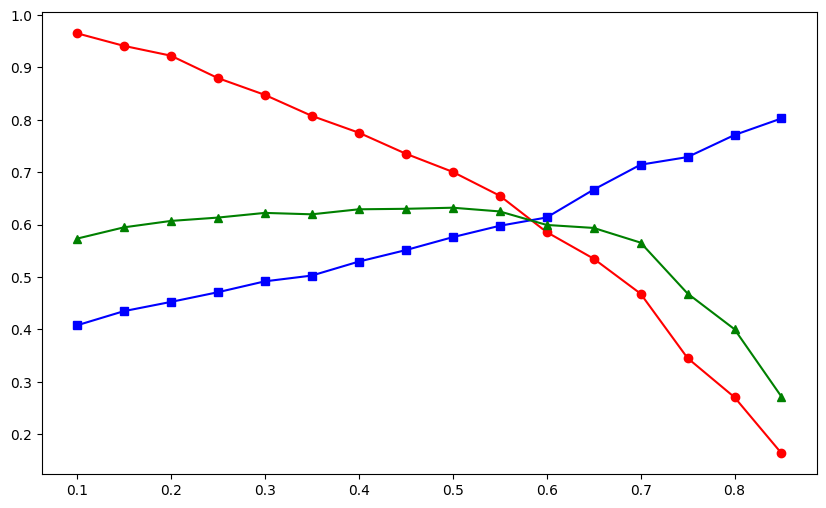

In [ ]:
# Probar distintos thresholds y graficar resultados
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import recall_score, precision_score, f1_score

# 1. Obtenemos las probabilidades del mejor modelo encontrado en el GridSearch
# (Si ya tienes 'y_prob_rf_smote' de la celda anterior, no pasa nada por sobreescribirlo)
y_prob_xgb_smote = best_pipeline_xgb.predict_proba(X_test)[:, 1]

# Generamos los umbrales
thresholds = np.arange(0.1, 0.9, 0.05)
results = []

for t in thresholds:
    # CLAVE: Redondeamos 't' a 2 decimales para evitar el ruido de np.arange
    t_round = round(t, 2)
    
    # Usamos el umbral redondeado limpiamente
    y_pred_t = (y_prob_xgb_smote >= t_round).astype(int)

    # Calculamos métricas (añadido zero_division=0 para evitar warnings de sklearn)
    recall = recall_score(y_test, y_pred_t)
    precision = precision_score(y_test, y_pred_t, zero_division=0)
    f1 = f1_score(y_test, y_pred_t)

    # Guardamos t_round para que la tabla quede bonita con 2 decimales
    results.append([t_round, recall, precision, f1])

# DataFrame con los resultados
results_rf_smote = pd.DataFrame(
    results,
    columns=["threshold", "recall", "precision", "f1"]
)

# Mostramos la tabla limpia
print("--- Tabla de Métricas por Umbral ---")
print(results_rf_smote.to_string(index=False))

plt.figure(figsize=(10, 6))

# Dibujamos las tres líneas
plt.plot(results_rf_smote['threshold'], results_rf_smote['recall'], marker='o', label='Recall (Fugas capturadas)', color='red')
plt.plot(results_rf_smote['threshold'], results_rf_smote['precision'], marker='s', label='Precision (Acierto en lo que predecimos)', color='blue')
plt.plot(results_rf_smote['threshold'], results_rf_smote['f1'], marker='^', label='F1-Score (Equilibrio)', color='green')



In [ ]:
#RANDOM FOREST Optimización Hiperparámetros

In [14]:
# modelo random forest con SMOTE
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
# crear pipeline
pipeline_rf_smote = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

In [15]:
# Entrenar
pipeline_rf_smote.fit(X_train, y_train)

,steps,"[('preprocessing', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. Th

In [ ]:
#predicciones
y_pred_rf_smote = pipeline_rf_smote.predict(X_test)
y_prob_rf_smote = pipeline_rf_smote.predict_proba(X_test)[:,1]

y_pred_rf_smote = (y_prob_rf_smote >= 0.25).astype(int)

In [ ]:
#Evaluación
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print(confusion_matrix(y_test, y_pred_rf_smote))
print(classification_report(y_test, y_pred_rf_smote))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf_smote)) 

In [16]:
# 8.1 Optimización de hiperparámetros con GridSearchCV
from sklearn.model_selection import GridSearchCV

# Definir la cuadrícula de valores a probar
# Usamos el prefijo 'model__' porque así llamaste al paso en el Pipeline
param_grid = {
    'model__n_estimators': [100, 200, 300],         # Número de árboles
    'model__max_depth': [None, 10, 20],             # Profundidad máxima
    'model__min_samples_split': [2, 5, 10],         # Muestras mínimas para dividir
    'model__class_weight': ['balanced', None]       # Prueba con y sin balanceo interno
}

# Configurar GridSearchCV
grid_search = GridSearchCV(
    estimator=pipeline_rf_smote,
    param_grid=param_grid,
    scoring='roc_auc',      # Optimizamos basándonos en el área bajo la curva
    cv=5,                   # Validación cruzada de 5 pliegues
    n_jobs=-1,              # Usa todos los procesadores disponibles
    verbose=2               # Muestra el progreso en pantalla
)

# Entrenar probando todas las combinaciones (esto tardará unos minutos)
print("Iniciando entrenamiento y optimización...")
grid_search.fit(X_train, y_train)

# Mostrar los mejores resultados encontrados
print("\n--- Resultados de GridSearchCV ---")
print(f"Mejor ROC-AUC en entrenamiento (CV): {grid_search.best_score_:.4f}")
print("Mejores hiperparámetros encontrados:")
print(grid_search.best_params_)

# Extraer el mejor modelo para usarlo en adelante
best_pipeline_rf = grid_search.best_estimator_

Iniciando entrenamiento y optimización...
Fitting 5 folds for each of 54 candidates, totalling 270 fits

--- Resultados de GridSearchCV ---
Mejor ROC-AUC en entrenamiento (CV): 0.8589
Mejores hiperparámetros encontrados:
{'model__class_weight': 'balanced', 'model__max_depth': 10, 'model__min_samples_split': 5, 'model__n_estimators': 100}


In [24]:
# predicciones con el MEJOR modelo encontrado
y_pred_rf_smote = best_pipeline_rf.predict(X_test)
y_prob_rf_smote = best_pipeline_rf.predict_proba(X_test)[:,1]

# Aplicar tu threshold personalizado de 0.25
y_pred_rf_smote = (y_prob_rf_smote >= 0.25).astype(int)

In [25]:
#Evaluación
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print(confusion_matrix(y_test, y_pred_rf_smote))
print(classification_report(y_test, y_pred_rf_smote))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf_smote)) 

[[614 421]
 [ 31 343]]
              precision    recall  f1-score   support

           0       0.95      0.59      0.73      1035
           1       0.45      0.92      0.60       374

    accuracy                           0.68      1409
   macro avg       0.70      0.76      0.67      1409
weighted avg       0.82      0.68      0.70      1409

ROC-AUC: 0.8489769820971867


--- Tabla de Métricas por Umbral ---
 threshold   recall  precision       f1
      0.10 0.983957   0.365079 0.532562
      0.15 0.959893   0.392350 0.557021
      0.20 0.933155   0.422518 0.581667
      0.25 0.917112   0.448953 0.602812
      0.30 0.887701   0.475645 0.619403
      0.35 0.844920   0.499210 0.627607
      0.40 0.807487   0.515358 0.629167
      0.45 0.764706   0.543726 0.635556
      0.50 0.721925   0.557851 0.629371
      0.55 0.679144   0.583908 0.627936
      0.60 0.625668   0.612565 0.619048
      0.65 0.553476   0.627273 0.588068
      0.70 0.502674   0.686131 0.580247
      0.75 0.422460   0.705357 0.528428
      0.80 0.315508   0.723926 0.439479
      0.85 0.205882   0.762376 0.324211


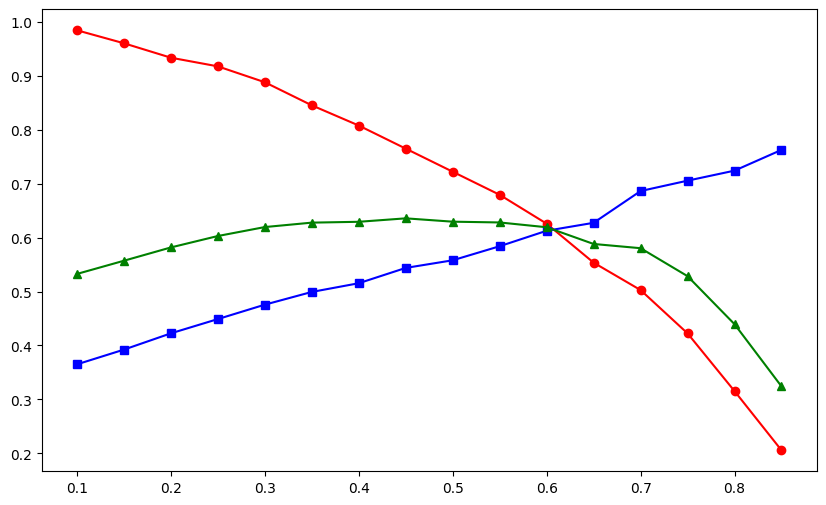

In [ ]:
# Probar distintos thresholds y graficar resultados
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import recall_score, precision_score, f1_score

# 1. Obtenemos las probabilidades del mejor modelo encontrado en el GridSearch
# (Si ya tienes 'y_prob_rf_smote' de la celda anterior, no pasa nada por sobreescribirlo)
y_prob_rf_smote = best_pipeline_rf.predict_proba(X_test)[:, 1]

# Generamos los umbrales
thresholds = np.arange(0.1, 0.9, 0.05)
results = []

for t in thresholds:
    # CLAVE: Redondeamos 't' a 2 decimales para evitar el ruido de np.arange
    t_round = round(t, 2)
    
    # Usamos el umbral redondeado limpiamente
    y_pred_t = (y_prob_rf_smote >= t_round).astype(int)

    # Calculamos métricas (añadido zero_division=0 para evitar warnings de sklearn)
    recall = recall_score(y_test, y_pred_t)
    precision = precision_score(y_test, y_pred_t, zero_division=0)
    f1 = f1_score(y_test, y_pred_t)

    # Guardamos t_round para que la tabla quede bonita con 2 decimales
    results.append([t_round, recall, precision, f1])

# DataFrame con los resultados
results_rf_smote = pd.DataFrame(
    results,
    columns=["threshold", "recall", "precision", "f1"]
)

# Mostramos la tabla limpia
print("--- Tabla de Métricas por Umbral ---")
print(results_rf_smote.to_string(index=False))

plt.figure(figsize=(10, 6))

# Dibujamos las tres líneas
plt.plot(results_rf_smote['threshold'], results_rf_smote['recall'], marker='o', label='Recall (Fugas capturadas)', color='red')
plt.plot(results_rf_smote['threshold'], results_rf_smote['precision'], marker='s', label='Precision (Acierto en lo que predecimos)', color='blue')
plt.plot(results_rf_smote['threshold'], results_rf_smote['f1'], marker='^', label='F1-Score (Equilibrio)', color='green')



In [ ]:
#Regresión Logística

In [45]:
#4.1 Importaciones
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression

#4.2 Crear pipeline con SMOTE
pipeline_smote = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", LogisticRegression(max_iter=1000))
])

In [46]:
#4.3 Entrenar modelo
pipeline_smote.fit(X_train, y_train)

,steps,"[('preprocessing', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. Th

In [47]:
# 8.3 Optimización de hiperparámetros para Regresión Logística
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# 1. Tu pipeline tal y como lo definiste
pipeline_smote = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", LogisticRegression(max_iter=1000, random_state=42)) # Añadimos random_state para reproducibilidad
])

# 2. Definir la cuadrícula de hiperparámetros
# Usamos el prefijo 'model__' porque así se llama el paso en tu Pipeline
param_grid_lr = {
    'model__C': [0.01, 0.1, 1, 10, 100],                 # Fuerza de regularización
    'model__penalty': ['l1', 'l2'],                      # Tipo de penalización (Lasso o Ridge)
    'model__solver': ['liblinear', 'saga']               # Algoritmos de optimización compatibles con l1 y l2
}

# 3. Configurar GridSearchCV
grid_search_lr = GridSearchCV(
    estimator=pipeline_smote,
    param_grid=param_grid_lr,
    scoring='roc_auc',      # Mantenemos ROC-AUC para comparar justamente con RF y XGBoost
    cv=5,                   # Validación cruzada de 5 pliegues
    n_jobs=-1,              # Usa todos los núcleos disponibles
    verbose=2               # Muestra el progreso (la regresión logística es muy rápida)
)

# 4. Entrenar probando todas las combinaciones
print("Iniciando entrenamiento y optimización de Regresión Logística...")
grid_search_lr.fit(X_train, y_train)

# 5. Mostrar los mejores resultados encontrados
print("\n--- Resultados de GridSearchCV para Regresión Logística ---")
print(f"Mejor ROC-AUC en entrenamiento (CV): {grid_search_lr.best_score_:.4f}")
print("Mejores hiperparámetros encontrados:")
print(grid_search_lr.best_params_)

# 6. Extraer el mejor modelo
best_pipeline_lr = grid_search_lr.best_estimator_

Iniciando entrenamiento y optimización de Regresión Logística...
Fitting 5 folds for each of 20 candidates, totalling 100 fits


c:\Users\edupu\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\edupu\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(



--- Resultados de GridSearchCV para Regresión Logística ---
Mejor ROC-AUC en entrenamiento (CV): 0.8585
Mejores hiperparámetros encontrados:
{'model__C': 0.1, 'model__penalty': 'l1', 'model__solver': 'saga'}


In [48]:
#4.4 Predicciones
y_pred_smote = best_pipeline_lr.predict(X_test)
y_prob_smote = best_pipeline_lr.predict_proba(X_test)[:,1]
y_pred_t = (y_prob_smote >= 0.4).astype(int)


In [49]:
#4.5 Evaluación base (threshold = 0.5)
print(confusion_matrix(y_test, y_pred_t))
print(classification_report(y_test, y_pred_t))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_t))

[[686 349]
 [ 51 323]]
              precision    recall  f1-score   support

           0       0.93      0.66      0.77      1035
           1       0.48      0.86      0.62       374

    accuracy                           0.72      1409
   macro avg       0.71      0.76      0.70      1409
weighted avg       0.81      0.72      0.73      1409

ROC-AUC: 0.7632191480017567


--- Tabla de Métricas por Umbral ---
 threshold   recall  precision       f1
      0.10 0.986631   0.354127 0.521186
      0.15 0.978610   0.381648 0.549137
      0.20 0.962567   0.407240 0.572337
      0.25 0.922460   0.419708 0.576923
      0.30 0.898396   0.439791 0.590510
      0.35 0.882353   0.455801 0.601093
      0.40 0.863636   0.480655 0.617591
      0.45 0.836898   0.496825 0.623506
      0.50 0.772727   0.513321 0.616862
      0.55 0.743316   0.535645 0.622620
      0.60 0.700535   0.556263 0.620118
      0.65 0.673797   0.594340 0.631579
      0.70 0.609626   0.612903 0.611260
      0.75 0.542781   0.665574 0.597938
      0.80 0.425134   0.706667 0.530885
      0.85 0.280749   0.777778 0.412574


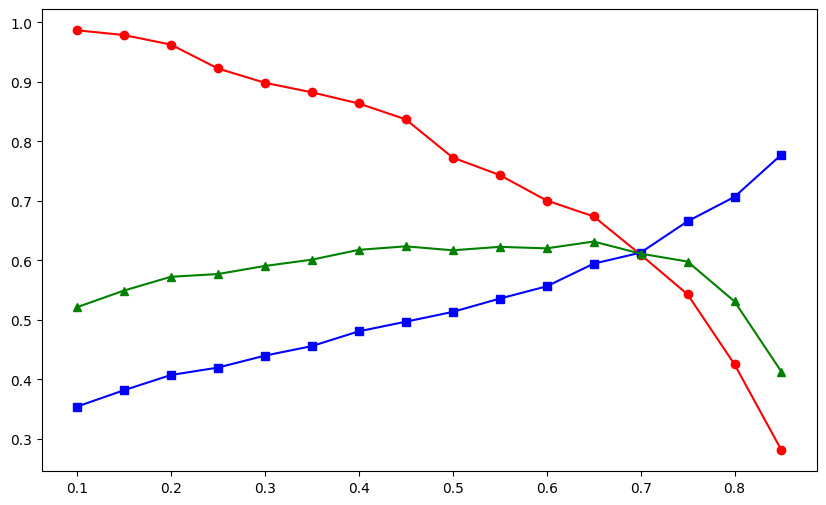

In [ ]:
# Probar distintos thresholds y graficar resultados
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import recall_score, precision_score, f1_score

# 1. Obtenemos las probabilidades del mejor modelo encontrado en el GridSearch
# (Si ya tienes 'y_prob_rf_smote' de la celda anterior, no pasa nada por sobreescribirlo)
y_prob_smote = best_pipeline_lr.predict_proba(X_test)[:, 1]

# Generamos los umbrales
thresholds = np.arange(0.1, 0.9, 0.05)
results = []

for t in thresholds:
    # CLAVE: Redondeamos 't' a 2 decimales para evitar el ruido de np.arange
    t_round = round(t, 2)
    
    # Usamos el umbral redondeado limpiamente
    y_pred_t = (y_prob_smote >= t_round).astype(int)

    # Calculamos métricas (añadido zero_division=0 para evitar warnings de sklearn)
    recall = recall_score(y_test, y_pred_t)
    precision = precision_score(y_test, y_pred_t, zero_division=0)
    f1 = f1_score(y_test, y_pred_t)

    # Guardamos t_round para que la tabla quede bonita con 2 decimales
    results.append([t_round, recall, precision, f1])

# DataFrame con los resultados
results_rf_smote = pd.DataFrame(
    results,
    columns=["threshold", "recall", "precision", "f1"]
)

# Mostramos la tabla limpia
print("--- Tabla de Métricas por Umbral ---")
print(results_rf_smote.to_string(index=False))

plt.figure(figsize=(10, 6))

# Dibujamos las tres líneas
plt.plot(results_rf_smote['threshold'], results_rf_smote['recall'], marker='o', label='Recall (Fugas capturadas)', color='red')
plt.plot(results_rf_smote['threshold'], results_rf_smote['precision'], marker='s', label='Precision (Acierto en lo que predecimos)', color='blue')
plt.plot(results_rf_smote['threshold'], results_rf_smote['f1'], marker='^', label='F1-Score (Equilibrio)', color='green')


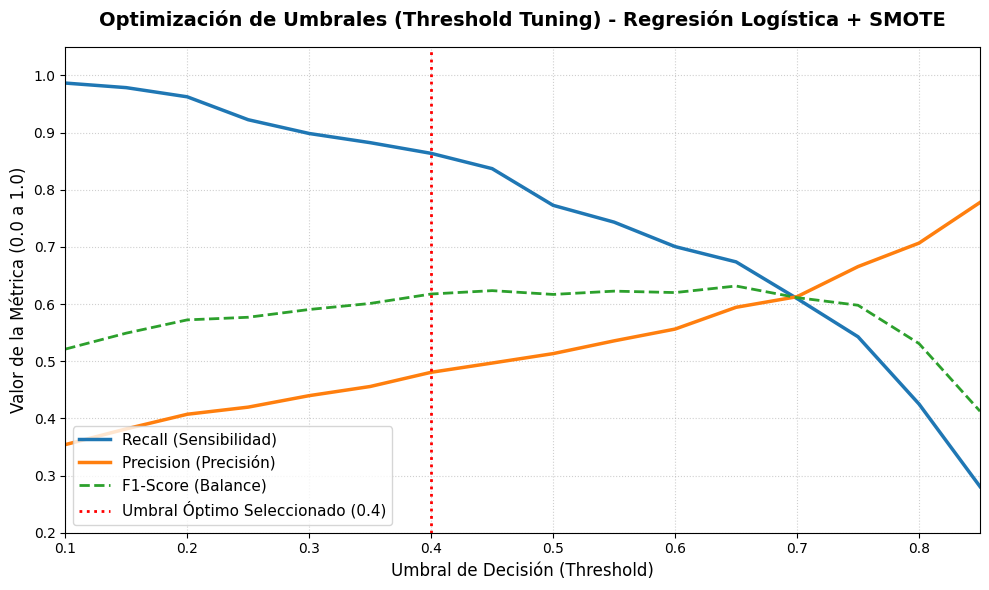

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import recall_score, precision_score, f1_score

# 1. Definimos los umbrales a evaluar
thresholds = np.arange(0.1, 0.9, 0.05)

# 2. Función auxiliar para calcular métricas y graficar
def graficar_threshold_tuning(y_true, y_probs, nombre_modelo, umbral_optimo):
    results = []
    
    # Calcular métricas para cada umbral
    for t in thresholds:
        y_pred_t = (y_probs >= t).astype(int)
        recall = recall_score(y_true, y_pred_t)
        precision = precision_score(y_true, y_pred_t)
        f1 = f1_score(y_true, y_pred_t)
        results.append([t, recall, precision, f1])
    
    # Convertir a DataFrame para facilitar el manejo
    df_metrics = pd.DataFrame(results, columns=["threshold", "Recall", "Precision", "F1-Score"])
    
    # Configuración de la gráfica
    plt.figure(figsize=(10, 6))
    plt.plot(df_metrics["threshold"], df_metrics["Recall"], label="Recall (Sensibilidad)", color="#1f77b4", linewidth=2.5)
    plt.plot(df_metrics["threshold"], df_metrics["Precision"], label="Precision (Precisión)", color="#ff7f0e", linewidth=2.5)
    plt.plot(df_metrics["threshold"], df_metrics["F1-Score"], label="F1-Score (Balance)", color="#2ca02c", linestyle="--", linewidth=2)
    
    # Línea vertical en el umbral seleccionado por negocio
    plt.axvline(x=umbral_optimo, color="red", linestyle=":", linewidth=2, 
                label=f"Umbral Óptimo Seleccionado ({umbral_optimo})")
    
    # Estética de la gráfica para el TFG
    plt.title(f"Optimización de Umbrales (Threshold Tuning) - {nombre_modelo}", fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Umbral de Decisión (Threshold)", fontsize=12)
    plt.ylabel("Valor de la Métrica (0.0 a 1.0)", fontsize=12)
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.xlim(0.1, 0.85)
    plt.ylim(0.2, 1.05)
    plt.legend(loc="lower left", fontsize=11)
    plt.tight_layout()
    plt.show()

# Gráfica: Regresión Logística (Punto óptimo: 0.40)
graficar_threshold_tuning(y_test, y_prob_smote, "Regresión Logística + SMOTE", umbral_optimo=0.4)